In [1]:
#### This script mostly deal with the use of Equilibirum/Adiabatic calculation of the non-eq density matrix.

In [273]:
using Pkg
Pkg.activate(joinpath(dirname((@__DIR__))))
#using TDNEGF

  Activating project at `/mnt/graphene/home/jalil2/Documents/Projects2026/TDNEGF`


In [274]:
using LinearAlgebra
using DifferentialEquations
using DelimitedFiles
using StaticArrays
using PyPlot
⊗(A,B) = kron(A,B) ;
include("types.jl")
include("selfenergy.jl")  
include("hamiltonians.jl")
include("poles.jl")

load_poles_square (generic function with 3 methods)

In [541]:
### Auxiliary functions 
@inline function get_sub(idx::Int, sub_dim::Int)
    ### Get the sub index range given the internal degrees of 
    ## such indexes 
    a = (idx-1)*sub_dim + 1
    b = idx*sub_dim
    return a:b
end
function Selfenergy(;E,H0l,H1l,Hlc,eta, epsilon=1e-12)
    "Calculation of the selfenergy. 
    The parameters needed are
    H0L : Supercell
    HLC: Matrix connecting the central system with the leads
    H1L : Hopping between super cells"
    one = Diagonal(ones(size(H0l)[1]))
    A0 = H1l'
    B0 = H1l
    C0 = (E + 1im*eta)*one - H0l
    D0 = (E +1im*eta)*one - H0l
    invD0 = inv(D0)
    while norm(A0) > epsilon
        #println(1)
        C = C0 - A0*invD0*B0
        D = D0 - A0*invD0*B0 - B0*invD0*A0
        A = A0*invD0*A0
        B = B0*invD0*B0
        ###################################
        A0 = A
        B0 = B
        C0 = C
        D0 = D
        invD0 =inv(D0)
    end
    g_L = inv(C0) ### Surface green function of the lead 
    Self = Hlc'*g_L*Hlc
end

Selfenergy (generic function with 1 method)

In [592]:
### Parameters to set the model in typical quasi-1d model for a tape with 2 semi-inifinite leads
Nx    = 1
Ny    = 2 
Nσ    = 2 
N_orb = 1 
Nα    = 2
γ     = 1.0
γso   = 0.0 + 0.0im
p = ModelParamsTDNEGF(Nx   = Nx, Ny   = Ny,  Nσ   = Nσ, N_orb = N_orb, #### dimension
                      Nα   = Nα, N_λ1 = 49 , N_λ2 = 20) ;

In [593]:
### We build the Hamialtonian system 
H_ab  = build_H_ab(;Nx = p.Nx,Ny = p.Ny, Nσ = p.Nσ, N_orb = p.N_orb, γ = γ, γso = γso) ;

In [594]:
H0,T = build_blocks(Ny   = Ny,  Nσ   = Nσ, N_orb = N_orb, γ = γ, γso = γso)
#### We calculate the components of the self energy ordered column-wise as julia do it automatically
Σ_num_m(ϵ) = Selfenergy(;E=ϵ,H0l=H0,H1l=T,Hlc=T,eta=1e-3, epsilon=1e-8)
Σ_num(ϵ,i) = Selfenergy(;E=ϵ,H0l=H0,H1l=T,Hlc=T,eta=1e-3, epsilon=1e-8)[i] 

Σ_num (generic function with 1 method)

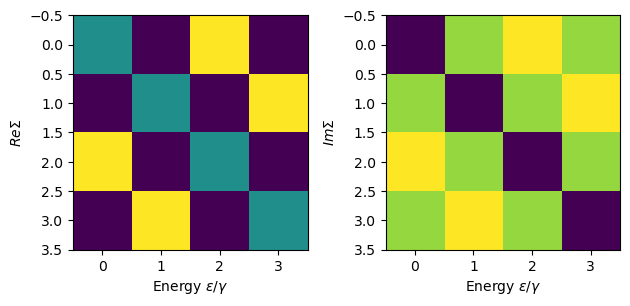

In [595]:
figs,axs = plt.subplots(1,2)
axs[1,1].set_xlabel(L"Energy$\ \epsilon/\gamma $")
axs[2,1].set_xlabel(L"Energy$\ \epsilon/\gamma  $")

axs[1,1].set_ylabel(L"Re Σ")
axs[2,1].set_ylabel(L"Im Σ")

axs[1,1].imshow(real(Σ_num_m(0.5)))
axs[2,1].imshow(imag(Σ_num_m(0.5)))
plt.tight_layout()

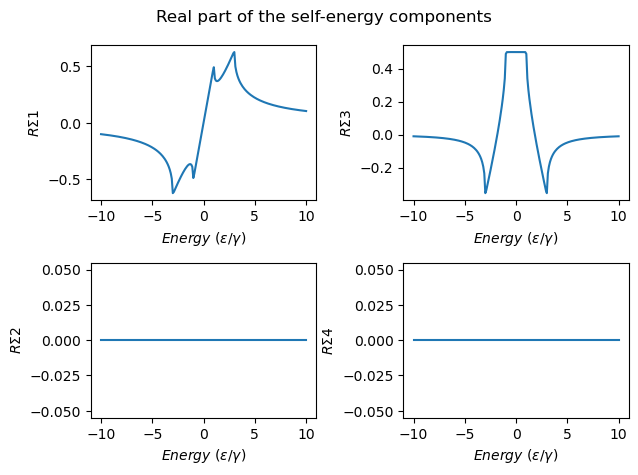

In [596]:

### Lets plot the real and imaginary parts of the self energy 
ϵs = -10γ:0.1:10γ
fig,axs = plt.subplots(2,2)
for i in 1:4#Ny*Nσ ### Number of channels for the reduced self energy 
    axs[i].plot(ϵs,real.(Σ_num.(ϵs,i)))
    axs[i].set_ylabel(L"$R\Sigma $"* "$(i)"    ) 
    axs[i].set_xlabel(L"$Energy\  (\epsilon/  \gamma)$")
end
fig.suptitle("Real part of the self-energy components")
plt.tight_layout()

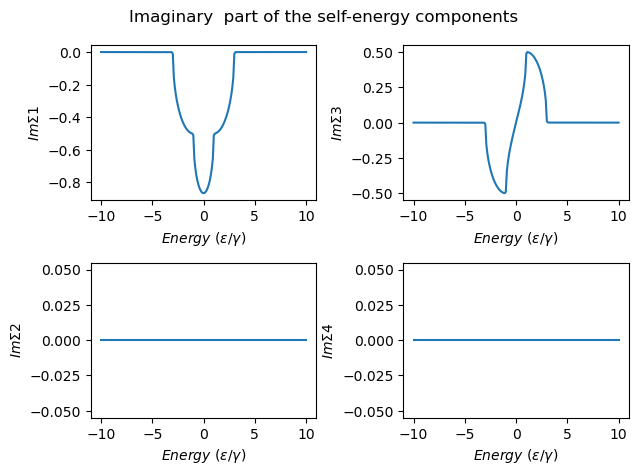

In [597]:
ϵs = -10γ:0.1:10γ
fig,axs = plt.subplots(2,2)
for i in 1:1:4 ### Number of channels for the reduced self energy 
    axs[i].plot(ϵs,imag.(Σ_num.(ϵs,i)))
    axs[i].set_ylabel(L"$Im\Sigma $"* "$(i)"    ) 
    axs[i].set_xlabel(L"$Energy\  (\epsilon/  \gamma)$")
end
fig.suptitle("Imaginary  part of the self-energy components")
plt.tight_layout()

In [598]:
### Now we calculate the selfenergy components in an analitycal way
## In order to calculate the self energy in a 2d tape lattice, we can use the 1d 
## Analytical expression 

function Σn_anal(ϵ::Union{ComplexF64,Float64}; n::Int, γ::Float64=1.0, γc::Float64=1.0, Ny::Int=5)
    ϵ_n = -2 * γ * cos(n * π / (Ny + 1))
    z   = ϵ - ϵ_n
    Δ   = z^2 - 4 * γ^2
    s   = sqrt(complex(Δ))

    # Choose retarded branch:
    #   Im(s) >= 0
    #   and if s is real, then s ~ z for large |z|
    if imag(s) < 0 || (isapprox(imag(s), 0.0; atol=1e-14) && real(s) * real(z) < 0)
        s = -s
    end

    Σ = (γc^2 / (2 * γ^2)) * (z - s)
    return Σ
end

function Σ_anal(ϵ::Union{ComplexF64,Float64}; γ::Float64 = 1.,γc::Float64= 1.0 ,Ny::Int=2,Nσ::Int = 2)
    ## Matrix components of the analitical expression for the self energy 
    
    # We use the unitary transformation to go back to the lattice basis
    U_in(i,n) = sin(n*i*pi/(Ny+1))*sqrt(2/(Ny+1))
    one_σ = Matrix{ComplexF64}(I, Nσ, Nσ)
    
    Σ = zeros(ComplexF64, Ny*Nσ, Ny*Nσ)
    for i in 1:Ny,j in 1:Ny
        i_idx = get_sub(i, Nσ*N_orb)
        j_idx = get_sub(j, Nσ*N_orb)

        for n_s in 1:Ny
             Σ[i_idx,j_idx] .+= U_in(i,n_s)*(Σn_anal(ϵ;n=n_s,γ=γ,γc=γc,Ny=Ny)*one_σ)*U_in(j,n_s)
        end
    end
    return  Σ
end

# #### Components of the Gamma function 
# function Γ_ij(ϵ;i,j,γ=1.,γc=1.,Ny=5)
#     Γ(ϵ,n) = -2*imag(gr_n(ϵ;n=n,γ=γ,γc=γc,Ny=Ny))
#     U_in(i,n) = sin(n*i*pi/(Ny+1))*sqrt(2/(Ny+1))
#     res = 0.0
#     for n_s in 1:Ny
#         res += U_in(i,n_s)*Γ(ϵ,n_s)*U_in(j,n_s)
#     end
#     return res
# end
### Note that the hopping conecting the central system and the reservouir is the same 
Σ_anal_m(ϵ)  = Σ_anal(ϵ;γ=γ,γc=γ , Ny=Ny , Nσ = Nσ )
Σ_anal_idx(ϵ,i)  = Σ_anal(ϵ;γ=γ,γc=γ , Ny=Ny , Nσ = Nσ )[i] 


Σ_anal_idx (generic function with 1 method)

In [599]:
#Σ_anal_m(0.0)

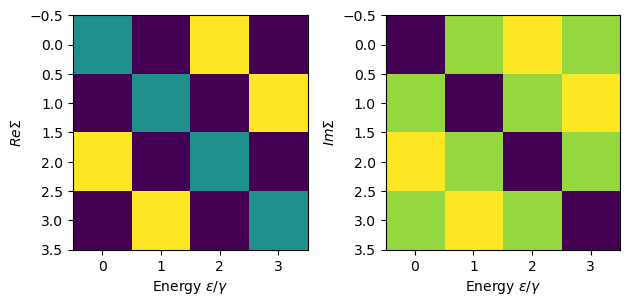

In [600]:
figs,axs = plt.subplots(1,2)
axs[1,1].set_xlabel(L"Energy$\ \epsilon/\gamma $")
axs[2,1].set_xlabel(L"Energy$\ \epsilon/\gamma  $")
axs[1,1].set_ylabel(L"Re Σ")
axs[2,1].set_ylabel(L"Im Σ")
axs[1,1].imshow(real(Σ_anal_m(0.5 + 0.0*im)))
axs[2,1].imshow(imag(Σ_anal_m(0.5 + 0.0*im)))
plt.tight_layout()

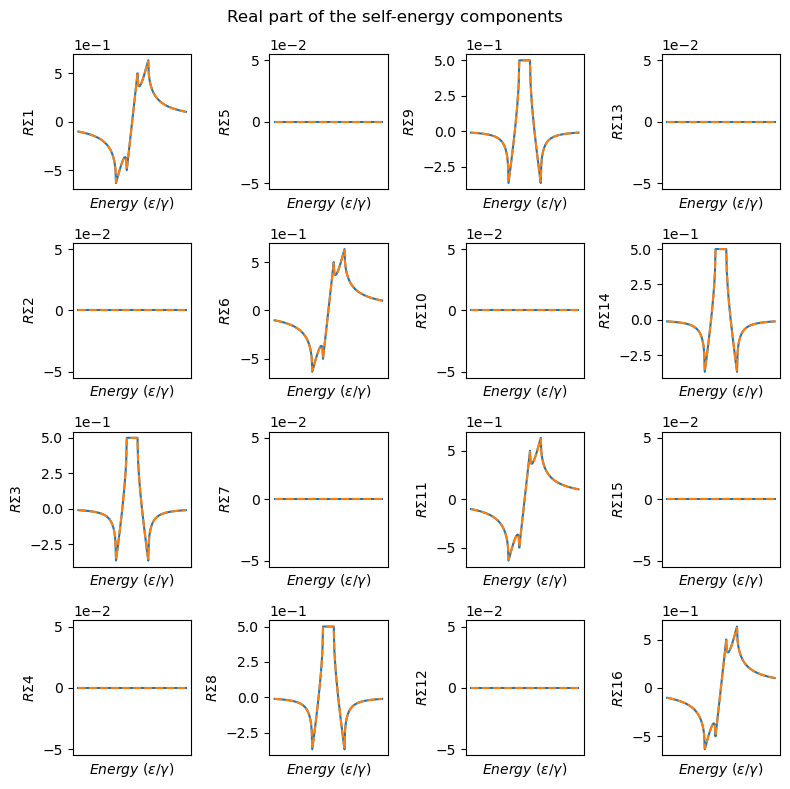

In [601]:
ϵs = complex(-10γ:0.1:10γ)
fig,axs = plt.subplots(Ny*Nσ,Ny*Nσ,figsize=(8,8))
for i in 1:1:(Ny*Nσ)^2 ### Number of channels for the reduced self energy 
    axs[i].plot(ϵs,real.(Σ_anal_idx.(ϵs,i) ))
    axs[i].plot(ϵs,real.(Σ_num.(ϵs,i)),ls = "--")
    axs[i].set_ylabel(L"$R\Sigma $"* "$(i)"    ) 
    axs[i].set_xlabel(L"$Energy\  (\epsilon/  \gamma)$")
    axs[i].set_xticks([]) 
    #axs[i].set_yticks([])
    axs[i].ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
end
fig.suptitle("Real part of the self-energy components")
plt.tight_layout()

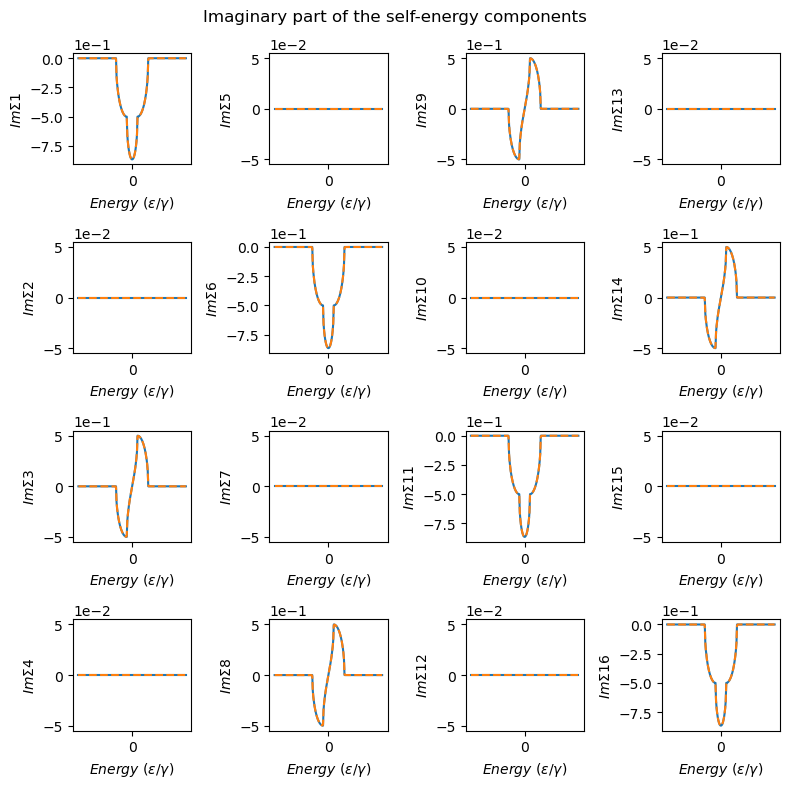

In [602]:
ϵs = complex(-10γ:0.1:10γ)
fig,axs = plt.subplots(Ny*Nσ,Ny*Nσ,figsize=(8,8))
for i in 1:1:(Ny*Nσ)^2 ### Number of channels for the reduced self energy 
    axs[i].plot(ϵs,imag.(Σ_anal_idx.(ϵs,i) ))
    axs[i].plot(ϵs,imag.(Σ_num.(ϵs,i)),ls ="--")
    axs[i].set_ylabel(L"$Im\Sigma $"* "$(i)"    ) 
    axs[i].set_xlabel(L"$Energy\  (\epsilon/  \gamma)$")
    axs[i].set_xticks([0.0]) 
    axs[i].ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
    #axs[i].set_yticks([])
end
fig.suptitle("Imaginary part of the self-energy components")
plt.tight_layout()

In [603]:
ϵs = complex(-10γ:0.1:10γ)
maximum(imag.(Σ_num.(ϵs,2) ))
### The peaks are numerical error to the order of the precession of the numerical calcualtions

0.0

In [604]:
### Thus... Now that we have analitycal expression for each component we can compute 
### The equilibirum density matrix using Pade method 
function pade_poles(M::Int)
    ### Calculates the residue and poles of the pade decomposition 
    @assert M ≥ 1 "The number of poles should be greater or equal than 1"
    M=2*M
    # Symmetric tridiagonal with off-diagonals b_n = 1 / (2*sqrt(4n^2 - 1))
    b = [1.0/(2*sqrt(4n^2 - 1.0)) for n in 1:M-1]
    T = SymTridiagonal(zeros(M), b)        # main diagonal zeros, off-diagonals b
    F = eigen(T)                           # F.values::Vector, F.vectors::Matrix
    λ = F.values
    V = F.vectors
    # keep positive eigenvalues
    pos = findall(>(0.0), λ)
    ξ = 1 ./λ[pos]                       # poles (imag-axis locations)
    η = norm.(V[1, pos]).^2 ./ (4.0*λ[pos].^2)             # weights = (first component)^2
    return -1im*ξ, -η #### note the -im by convention 
end

## Calculation of the total self energy 
function Σ_tot(ϵ::Union{Float64,ComplexF64}; γ::Float64=1., γc::Float64=1.0, Nx::Int=1, Ny::Int=2, Nσ::Int=2)
    ## Total embedding self-energy matrix for left and right leads
    dim = Nx * Ny * Nσ
    Σ_t = zeros(ComplexF64, dim, dim)
    # Self-energy block for each lead contact surface (size Ny*Nσ)
    Σ_L = Σ_anal(ϵ; γ=γ, γc=γc, Ny=Ny, Nσ=Nσ)
    Σ_R = Σ_anal(ϵ; γ=γ, γc=γc, Ny=Ny, Nσ=Nσ)
    # Left contact: first x-slice
    iL = 1 : Ny * Nσ
    # Right contact: last x-slice
    iR = dim - Ny * Nσ + 1 : dim
    Σ_t[iL, iL] .+= Σ_L
    Σ_t[iR, iR] .+= Σ_R
    return Σ_t
end

function ΣL_tot(ϵ::Union{Float64,ComplexF64}; γ::Float64=1., γc::Float64=1.0, Nx::Int=1, Ny::Int=2, Nσ::Int=2)
    ## Total embedding self-energy matrix for left and right leads
    dim = Nx * Ny * Nσ
    Σ_t = zeros(ComplexF64, dim, dim)
    # Self-energy block for each lead contact surface (size Ny*Nσ)
    Σ_L = Σ_anal(complex(ϵ); γ=γ, γc=γc, Ny=Ny, Nσ=Nσ)
    iL = 1 : Ny * Nσ
    Σ_t[iL, iL] .+= Σ_L
    return Σ_t
end

function ΣR_tot(ϵ::Union{Float64,ComplexF64}; γ::Float64=1., γc::Float64=1.0, Nx::Int=1, Ny::Int=2, Nσ::Int=2)
    ## Total embedding self-energy matrix for left and right leads
    dim = Nx * Ny * Nσ
    Σ_t = zeros(ComplexF64, dim, dim)
    # Self-energy block for each lead contact surface (size Ny*Nσ)
    Σ_R = Σ_anal(ϵ; γ=γ, γc=γc, Ny=Ny, Nσ=Nσ)
    # Left contact: first x-slice
    # Right contact: last x-slice
    iR = dim - Ny * Nσ + 1 : dim
    Σ_t[iR, iR] .+= Σ_R
    return Σ_t
end

### Now The retarded component GF should be computed 
function Gr(ϵ::Union{Float64,ComplexF64} ,H::Matrix{ComplexF64}, Σ;η=0.02)
    dims= size(H)[1]
    one = Matrix{ComplexF64}(I, dims,dims  )
    G = inv((ϵ + 1im*η )*one - H - Σ(complex(ϵ)) )
    return G
end

### Now The advanced component GF should be computed 
function Ga(ϵ::Union{Float64,ComplexF64} ,H::Matrix{ComplexF64}, Σ;η=1e-2)
    #η = 1e-2
    dims= size(H)[1]
    one = Matrix{ComplexF64}(I, dims,dims  )
    
    G = inv(  ((ϵ + 1im*η )*one - H - Σ(complex(ϵ)) )' )
    return G
end

function ρ_eq(ϵ_f::Float64, β::Float64, Gr, Np::Int; Rtail::Float64=1e12)
    z_p, R_p = pade_poles(Np)   # z_p = -im*ξ, R_p = -η

    Gtmp = Gr(ϵ_f + conj(z_p[1]) / β)
    acc = zeros(eltype(Gtmp), size(Gtmp))

    for i in eachindex(z_p)
        pole = ϵ_f + conj(z_p[i]) / β   # = μ + iξ/β
        acc .+= (-R_p[i]) .* Gr(pole)   # = η * G
    end

    X = (2im / β) .* acc
    ρ = (X .- X') ./ (2im)

    moment = 0.5im * Rtail .* Gr(1im * Rtail)

    return ρ + moment
end


ρ_eq (generic function with 1 method)

In [605]:
Σ_anal_T(ϵ)  = Σ_tot(ϵ;γ=γ,γc=γ ,Nx = Nx, Ny=Ny , Nσ = Nσ )

GG(ϵ) = Gr(ϵ,H_ab,Σ_anal_T)
GG_idx(ϵ,j) = Gr(ϵ,H_ab,Σ_anal_T)[j]
GGa_idx(ϵ,j) = Ga(ϵ,H_ab,Σ_anal_T)[j]

rho_m(ϵf) = ρ_eq(ϵf,1.0, GG , 80 ;Rtail= 1e20)
rho(ϵf,i) = ρ_eq(ϵf,1.0, GG , 80 ;Rtail= 1e20)[i]
# transpose(conj(Σ_anal_T(0.1)))

rho (generic function with 1 method)

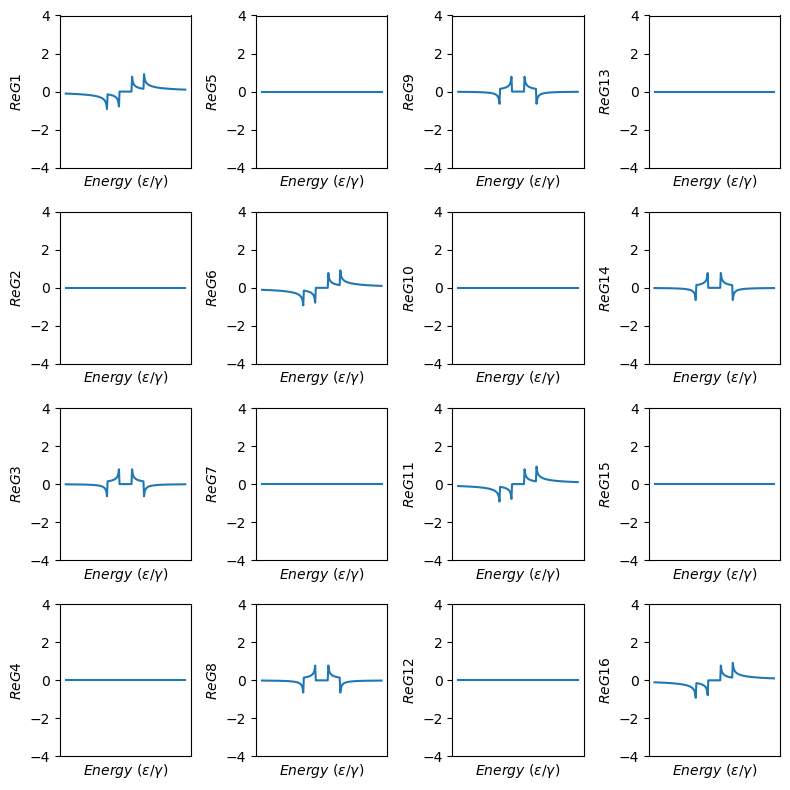

In [606]:

ϵs = -10:0.1:10
fig,axs = plt.subplots(Ny*Nσ,Ny*Nσ,figsize = (8,8))
for i in 1:(Ny*Nσ)^2#16#(Ny*Nσ)^2 ### Number of channels for the reduced self energy 
    axs[i].plot(ϵs,real(GG_idx.(ϵs,i) ))
    axs[i].set_ylabel(L"$Re G$"* "$(i)"    ) 
    axs[i].set_xlabel(L"$Energy\  (\epsilon/  \gamma)$")
    axs[i].set_ylim(-4,4)
    #axs[i].set_xticks([-3γ,-2γ,-1γ,0.0,1γ,2γ,3γ]) 
    axs[i].set_xticks([])
    #axs[i].set_yticks([])
    axs[i].ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

    
    # axs[i].set_xlim([0.0,4γ])
end
plt.tight_layout()

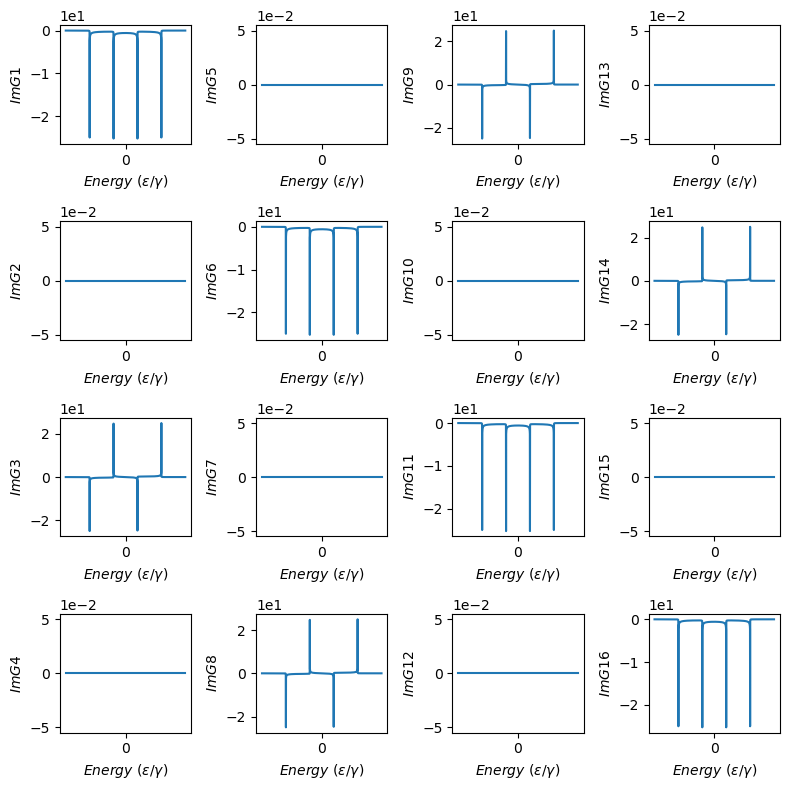

In [607]:
ϵs = -5:0.01:5
fig,axs = plt.subplots(Ny*Nσ,Ny*Nσ,figsize = (8,8))
for i in 1:(Ny*Nσ)^2#16#(Ny*Nσ)^2 ### Number of channels for the reduced self energy 
    axs[i].plot(ϵs,imag(GG_idx.(ϵs,i) ))
    axs[i].set_ylabel(L"$Im G$"* "$(i)"    ) 
    axs[i].set_xlabel(L"$Energy\  (\epsilon/  \gamma)$")
    #axs[i].set_yticks([0.0])
    axs[i].set_xticks([0.0])
    axs[i].ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
    #axs[i].set_xticks([-3γ,-2γ,-1γ,0.0,1γ,2γ,3γ]) 
    # axs[i].set_yticks([0.0])
    # axs[i].set_xlim([0.0,4γ])
    #axs[i].set_ylim(-4,4)
end
#plt.ylim(-2,2)
plt.tight_layout()

In [608]:
maximum(imag(GG_idx.(ϵs,2)))

0.0

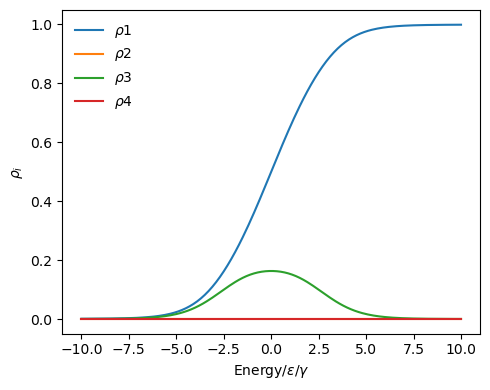

In [609]:
plt.figure(figsize = (5,4))
ϵs = -10:0.1:10
for i in 1:4
    plt.plot(ϵs,rho.(ϵs,i),label =  L"$\rho$"*"$(i)" )
end
plt.ylabel(L"$\rho_i$")
plt.xlabel(L"$\mathrm{Energy} / \epsilon / \gamma$")


plt.legend(frameon= false)
plt.tight_layout()

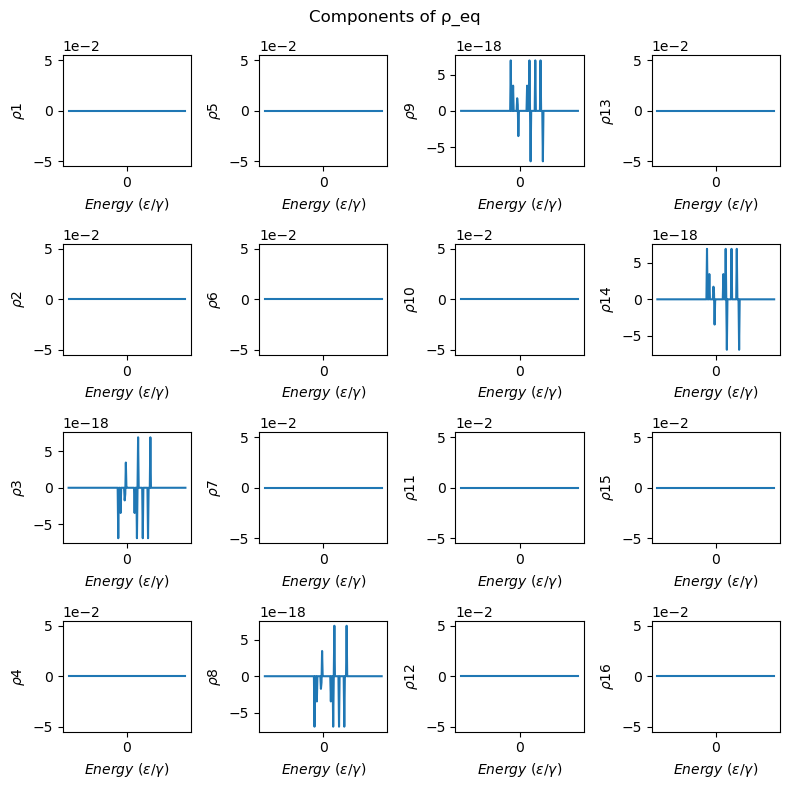

In [610]:


ϵs = -10:0.1:10
fig,axs = plt.subplots(Ny*Nσ,Ny*Nσ,figsize = (8,8))
for i in 1:(Ny*Nσ)^2#16#(Ny*Nσ)^2 ### Number of channels for the reduced self energy 
    axs[i].plot(ϵs,imag(rho.(ϵs,i)) )
    axs[i].set_ylabel(L"$ρ$"* "$(i)"    ) 
    axs[i].set_xlabel(L"$Energy\  (\epsilon/  \gamma)$")
    #axs[i].set_xticks([-3γ,-2γ,-1γ,0.0,1γ,2γ,3γ]) 
    #axs[i].set_yticks([0.0])
    axs[i].set_xticks([0.0])
    axs[i].ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
    #axs[i].set_ylim(-0.1,1.1)
    # axs[i].set_xlim([0.0,4γ])
end
fig.suptitle("Components of ρ_eq")
#plt.xlim(0.0,8)
plt.tight_layout()
# plt.plot(ϵs,-imag(GG.(ϵs))/pi )
# plt.plot(ϵs,real(GG.(ϵs))/pi )

In [611]:
#maximum(real(rho.(ϵs,4)))

In [621]:
function fermi(E::Float64, μ::Float64, β::Float64)
    return 1.0 / (exp(β * (E - μ)) + 1.0)
end

function Γ(Σα, E::Float64)
    Σr = Σα(ComplexF64(E))
    return 1im .* (Σr .- Σr')
end

function K_neq(E::Float64, μL::Float64, μR::Float64, μ0::Float64, β::Float64, GG, ΣL, ΣR, Nx, Ny, Nσ)
    GrE = GG(ComplexF64(E))
    GaE = GrE'
    # println(size(GrE))
    ΣL0 = ΣL(E; Nx=Nx, Ny=Ny, Nσ=Nσ)
    ΣR0 = ΣR(E; Nx=Nx, Ny=Ny, Nσ=Nσ)
    ΓL = 1im .* (ΣL0 .- ΣL0')
    ΓR = 1im .* (ΣR0 .- ΣR0')

    # println(size(ΣL(0.2)))
    # println(size(ΓL))
    δfL = fermi(E, μL, β) - fermi(E, μ0, β)
    δfR = fermi(E, μR, β) - fermi(E, μ0, β)
    #GrE * (ΓL .* δfL + ΓR .* δfR) * GaE
    return GrE * (ΓL.* δfL ) * GaE
end

E = 0.0 
ΓL0 = Γ(ΣR_tot, E)
K0_E(E,i) = K_neq(E, 0.5 , 0.0, 0.0, 33.0, GG, ΣL_tot, ΣR_tot, Nx, Ny, Nσ)[i]

K0_E (generic function with 1 method)

In [622]:
ϵs = -10:0.01:10 #.+ 1im*1e-2
maximum(real(K0_E.(ϵs,1)))

0.5845368836801603

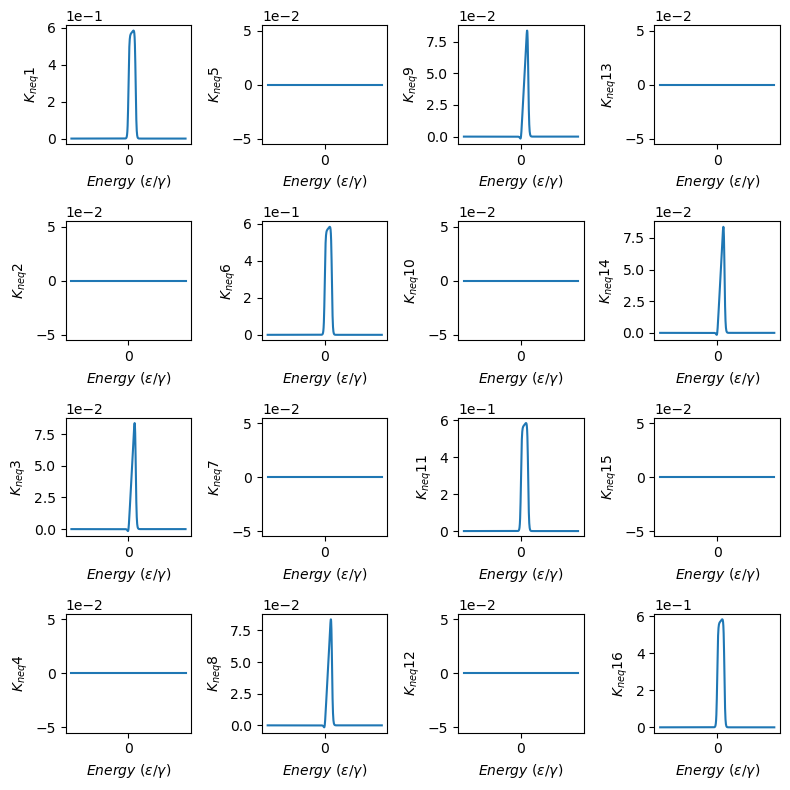

In [623]:
# K0 == K0'

ϵs = -4:0.01:4
fig,axs = plt.subplots(Ny*Nσ,Ny*Nσ,figsize = (8,8))
for i in 1:(Ny*Nσ)^2#16#(Ny*Nσ)^2 ### Number of channels for the reduced self energy 
    axs[i].plot(ϵs, real(K0_E.(ϵs,i)))
    axs[i].set_ylabel(L"$K_{neq}$"* "$(i)"  ) 
    axs[i].set_xlabel(L"$Energy\  (\epsilon/  \gamma)$")
    #axs[i].set_xticks([-3γ,-2γ,-1γ,0.0,1γ,2γ,3γ]) 
    #axs[i].set_yticks([0.0])
    axs[i].set_xticks([0.0])
    axs[i].ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
    #axs[i].set_ylim([-0.01,0.2])
    #axs[i].set_xlim([0.0,4γ])
end
#plt.ylim(-0.001,0.001)
plt.tight_layout()

## Use of MPM to approaximate Ga as an anatyical continuation with poles in the lower semiplane

In [266]:
# using PyCall
# np = pyimport("numpy")
# np.complex_ = np.complex128
# minipole = pyimport("mini_pole")
# MiniPoleRf = minipole.MiniPoleRf


PyObject <class 'mini_pole.mini_pole_rf.MiniPoleRf'>

In [270]:

# # Retarded Bethe GF
# function Gr_bethe(z::ComplexF64; t::Float64=1.0)
#     Δ = z^2 - (2t)^2
#     s = sqrt(Δ)

#     # retarded branch
#     if imag(s) < 0 || (isapprox(imag(s), 0.0; atol=1e-14) && real(s) * real(z) < 0)
#         s = -s
#     end

#     return (z - s) / (2t^2)
# end



# GG_idx(ϵ,j) = Gr(ϵ,H_ab,Σ_anal_T)[j]

# GGa_idx(ϵ,j) = Ga(ϵ,H_ab,Σ_anal_T)[j]


# function Gr_real(E::Real; t::Float64=1.0, η::Float64=1e-6)
#     return Gr_bethe(ComplexF64(E + 1im*η); t=t)
# end
#### Ga cannot be approximated, thus the best option is to use the Kernel K_neq 
#
# GG_idx(Float64(E),1)
# G_rf = PyObject[
#     pyfunction(E -> K0_E(Float64(E),1), PyAny)
# ]

# G_rf = PyObject[
#     pyfunction(E -> GG_idx(Float64(E),1), PyAny)
# ]

# p = MiniPoleRf(
#     G_rf;
#     func_type="complex",
#     interval_type="infinite",
#     wp_max=1.0,
#     err=1e-6,              # start looser
#     compute_const=false
# )


#p = MiniPoleRf(G_rf;func_type="complex", interval_type="infinite", wp_max=3.0, err=1.e-9, k_max=1000) #func_type="complex"

# p3 = MiniPoleRf([bethe_lattice_dos], interval_type="infinite", wp_max=3, err=1.e-11, k_max=1000)

PyObject <mini_pole.mini_pole_rf.MiniPoleRf object at 0x7f9cf1ab9c40>

In [271]:
# G_rf = PyObject[
#     pyfunction(E -> K0_E(E::ComplexF64,1), PyAny)
# ]

In [272]:
# poles   = Vector{ComplexF64}(p.pole_location)
# weights = Array{ComplexF64}(p.pole_weight)

29×1×1 Array{ComplexF64, 3}:
[:, :, 1] =
  0.009497062028454881 - 0.007473344159003363im
  0.009832917338595894 - 0.009124612822028786im
  0.007348074475702508 - 0.0028026749840439156im
  0.010676090943286854 - 0.010404907544102112im
   0.01211818044582136 - 0.011994168565422205im
  0.014276827568421234 - 0.014129570864057786im
   0.01732965446363586 - 0.016954482498671215im
   0.02152126833557962 - 0.020556646019961787im
  0.027209197057451256 - 0.024941684821594128im
  0.034943329878936155 - 0.029937738901128212im
   0.04554773215897147 - 0.034944183504169245im
   0.06002707766821217 - 0.038350171114132144im
   0.07863683984088624 - 0.03656659727466709im
                       ⋮
   0.06002707146961399 + 0.038350166588976366im
   0.04554772914808127 + 0.034944179359722355im
   0.03494332857032301 + 0.029937736371503033im
   0.02720919682706797 + 0.024941683426748264im
   0.02152126871944907 + 0.02055664513181785im
   0.01732965493552915 + 0.016954481737355837im
  0.014276827834437511 

In [243]:
# function Gr_aux(z::Number)
#     zz = ComplexF64(z)
#     out = 0.0 + 0.0im
#     @inbounds for j in eachindex(poles)
#         out += weights[j, 1, 1] / (zz - poles[j])
#     end
#     return out
# end

# for E in (-2.5, -1.5, -0.5, 0.0, 0.5, 1.5, 2.5)
#     println("E = ", E)
#     println(" exact = ", Gr_real(E))
#     println(" fit   = ", Gr_aux(E))
#     println()
# end

Gr_aux (generic function with 1 method)

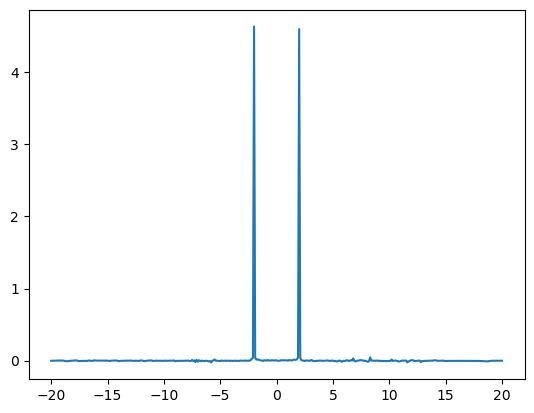

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f9cf054df40>

In [244]:
#ϵs = -20:0.1:20
#plt.plot(ϵs,real(Gr_aux.(ϵs )) )
#plt.ylim(-5,5)

In [245]:
# function residue_integral(poles, residues)
#     s = zero(residues[1])
#     @inbounds for (z, r) in zip(poles, residues)
#         imag(z) < 0 && (s += r)   # lower half-plane
#     end
#     return -1im * s # asuming the 2pi of the FT 2π * 
# end

residue_integral (generic function with 1 method)

In [246]:
#residue_integral(poles,weights[:,1,1])

-60.10285330487795 - 3.7220600429425694im

In [247]:
#weights

In [248]:
# function direct_integral_trapz(f, Emin, Emax, N)
#     Es = collect(range(Emin, Emax; length=N))
#     vals = f.(Es)
#     dE = Es[2] - Es[1]
#     return dE * (sum(vals) - 0.5 * (vals[1] + vals[end]))
# end

direct_integral_trapz (generic function with 1 method)

In [249]:
# K11(E) = K0_E(E,1)

K11 (generic function with 1 method)

In [251]:
# I_direct = real(direct_integral_trapz(K11, -10, 10, 100000)/(2pi))
# I_res    = real(residue_integral(poles, weights))

# println("direct = ", I_direct)
# println("residue = ", I_res)
# println("abs diff = ", abs(I_direct - I_res))

direct = 0.04509020070705513
residue = -60.10285330487795
abs diff = 60.147943505585005


In [ ]:
# direct = 0.03336207424001528
# residue = -0.22831817165241497
# abs diff = 0.2616802458924302

In [243]:

# ϵ0 = 0.5
# η  = 0.2

# Ga_scalar(E::Real) = 1 / (E - ϵ0 - 1im * η)

# # IMPORTANT: only ONE PyAny because MiniPoleRf passes one argument: E
# # G_rf = PyObject[
# #     pyfunction(E -> Ga_scalar(Float64(E)), PyAny)
# # ]

# # p = MiniPoleRf(
# #     [G_rf];
# #     func_type="complex",
# #     interval_type="infinite",
# #     wp_max=1.0,
# #     err=1e-8,
# #     compute_const=false
# # )

# p3 = MiniPoleRf([Ga_scalar], interval_type="infinite", wp_max=3, err=1.e-8)#, k_max=400)


LoadError: PyError ($(Expr(:escape, :(ccall(#= /home/jalil2/.julia/packages/PyCall/1gn3u/src/pyfncall.jl:43 =# @pysym(:PyObject_Call), PyPtr, (PyPtr, PyPtr, PyPtr), o, pyargsptr, kw))))) <class 'TypeError'>
TypeError('must be real number, not complex')
  File "/home/jalil2/.conda/envs/env/lib/python3.12/site-packages/mini_pole/mini_pole_rf.py", line 56, in __init__
    self.cal_hk_inf(self.G_rf, self.k_max, self.sing_vals)
  File "/home/jalil2/.conda/envs/env/lib/python3.12/site-packages/mini_pole/mini_pole_rf.py", line 109, in cal_hk_inf
    self.h_k[k, i] += self.cal_hk_inf_indiv(G_approx[i], k, tol, theta_min, theta_max)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jalil2/.conda/envs/env/lib/python3.12/site-packages/mini_pole/mini_pole_rf.py", line 117, in cal_hk_inf_indiv
    return (0.5  / np.pi) * integrate.quad(lambda x: G_approx(self.con_map.w_max / np.tan(0.5 * x)), theta_min, theta_max, weight="cos", wvar=k + 1, complex_

In [702]:
#f.(Complex.(ϵs))

In [ ]:
# Base.@kwdef struct ModelParamsAdiabatic


#     ### Surface indexes 
#     idx_surface = 


#     ### Precomputed adiabatic elements 
#     H_ad  =
#     Σ_ad  =
#     G_ad  =
    
#     #### Principal object
#     ρ_ad  =


# end

In [ ]:
### Auxiliary functions 
#@inline ϵ_n(n::Int,Ny::Int ;γ::Float64 = 1.0) = -2*γ*cos(n*pi/(Ny+1)) 

In [ ]:
# function green_n(n::Int,Ny::Int ;γ::Float64 = 1.0,γc::Float64 = 1.0)
#     ### This function computes the retarded Green function in the diagonal basis 
#     ### for a channel index n 
#     Δ = 4 * γ^2 - (ϵ - ϵ_n)^2
#     if real(Δ) > 0
#         Σ = ϵ - ϵ_n - im*sqrt(Δ)
#     else
#         if real(ϵ - ϵ_n) > 0
#             sgn = 1
#         else
#             sgn = -1
#         end
#         Σ  = ϵ-ϵ_n - sgn * sqrt(-Δ)
#     end
#     Σ = Σ* (γc^2 / (2 * γ^2))
#     return Σ
# end

# function green(Ny::Int ;γ::Float64 = 1.0,γc::Float64 = 1.0)
#     ### This function computes the exact green function for 2D lattice tape
#     ### in the original basis (Nx Ny N_spin N_orb)
    
    
    